# TPC-C Multi-Tenant with Distributed PVC and Tuned PostgreSQL 17.5

* data is generated and loaded into databases in a distributed filesystem
* experiments do not use preloaded data

* PostgreSQL uses improved args:
```
# --- Connection & Worker Processes ---
- "-c"
- "max_connections=1500"       # https://www.postgresql.org/docs/current/runtime-config-connection.html#GUC-MAX-CONNECTIONS
- "-c"
- "max_worker_processes=128"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-WORKER-PROCESSES
- "-c"
- "max_parallel_workers=64"    # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS
- "-c"
- "max_parallel_workers_per_gather=8"  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-WORKERS-PER-GATHER
- "-c"
- "max_parallel_maintenance_workers=8" # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-PARALLEL-MAINTENANCE-WORKERS

# --- Memory Settings ---
- "-c"
- "shared_buffers=256GB"       # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-SHARED-BUFFERS
- "-c"
- "effective_cache_size=350GB" # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-EFFECTIVE-CACHE-SIZE
- "-c"
- "work_mem=128MB"             # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-WORK-MEM
- "-c"
- "maintenance_work_mem=4GB"   # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAINTENANCE-WORK-MEM
- "-c"
- "temp_buffers=64MB"          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-TEMP-BUFFERS
- "-c"
- "wal_buffers=16MB"           # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-BUFFERS
- "-c"
- "autovacuum_work_mem=1GB"    # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-WORK-MEM

# --- Autovacuum ---
- "-c"
- "autovacuum=on"                            # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM
- "-c"
- "autovacuum_max_workers=10"               # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-MAX-WORKERS
- "-c"
- "autovacuum_vacuum_cost_limit=1000"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-LIMIT
- "-c"
- "vacuum_cost_limit=1000"                  # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-VACUUM-COST-LIMIT
- "-c"
- "autovacuum_naptime=15s"                  # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-NAPTIME
- "-c"
- "autovacuum_vacuum_cost_delay=20ms"       # https://www.postgresql.org/docs/current/runtime-config-autovacuum.html#GUC-AUTOVACUUM-VACUUM-COST-DELAY

# --- WAL & Checkpoints (Ceph-optimized) ---
- "-c"
- "wal_level=replica"                       # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-LEVEL
- "-c"
- "wal_compression=on"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-COMPRESSION
- "-c"
- "wal_writer_delay=500ms"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-WAL-WRITER-DELAY
- "-c"
- "commit_delay=10000"                      # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-COMMIT-DELAY
- "-c"
- "synchronous_commit=off"                  # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-SYNCHRONOUS-COMMIT
- "-c"
- "max_wal_size=2GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MAX-WAL-SIZE
- "-c"
- "min_wal_size=1GB"                        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-MIN-WAL-SIZE
- "-c"
- "checkpoint_timeout=15min"                # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-TIMEOUT
- "-c"
- "checkpoint_completion_target=0.9"        # https://www.postgresql.org/docs/current/runtime-config-wal.html#GUC-CHECKPOINT-COMPLETION-TARGET

# --- Planner Cost Tweaks (CephFS) ---
- "-c"
- "random_page_cost=4.0"                    # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-RANDOM-PAGE-COST
- "-c"
- "seq_page_cost=1.5"                       # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-SEQ-PAGE-COST
- "-c"
- "cpu_tuple_cost=0.01"                     # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-CPU-TUPLE-COST
- "-c"
- "effective_io_concurrency=2"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-EFFECTIVE-IO-CONCURRENCY
- "-c"
- "default_statistics_target=500"           # https://www.postgresql.org/docs/current/runtime-config-query.html#GUC-DEFAULT-STATISTICS-TARGET

# --- Locks and Limits ---
- "-c"
- "max_locks_per_transaction=128"           # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-LOCKS-PER-TRANSACTION
- "-c"
- "max_pred_locks_per_transaction=128"      # https://www.postgresql.org/docs/current/runtime-config-locks.html#GUC-MAX-PRED-LOCKS-PER-TRANSACTION
- "-c"
- "max_stack_depth=7MB"                     # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-STACK-DEPTH
- "-c"
- "max_files_per_process=4000"              # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-MAX-FILES-PER-PROCESS

# --- Miscellaneous ---
- "-c"
- "huge_pages=try"                          # https://www.postgresql.org/docs/current/runtime-config-resource.html#GUC-HUGE-PAGES
```

In [1]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import re
import numpy as np

from bexhoma import collectors

%matplotlib inline

# Functions for Nice Plots

In [18]:
def sanitize_filename(title, max_length=100):
    # Replace non-alphanumeric characters with underscores
    safe = re.sub(r'[^a-zA-Z0-9-_]+', '_', title.strip())
    # Truncate to a safe length
    return safe[:max_length].rstrip('_')
    
def plot_bars(df, y, title, estimator):
    df_plot = df.copy()
    #df_plot = df_plot[df_plot['client']=='1']
    df_plot = df_plot.sort_values(['num_tenants','type'])
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema', 'volume']
    # Create the plot
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x='num_tenants',
        y=y,
        hue='type',
        estimator=estimator,
        palette='Set2',
        hue_order=hue_order
    )
    show_height = False
    if show_height:
        for bar in ax.patches:
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,  # X: center of bar
                    height,                             # Y: top of bar
                    f'{height:.1f}',                    # Text (1 decimal place)
                    ha='center', va='bottom', fontsize=8
                )
    # Get tick positions (i.e., the x-axis categories)
    xticks = ax.get_xticks()
    bar_width = ax.patches[0].get_width()
    # Create a mapping from (num_tenants, type) to hatch
    grouped = df_plot.groupby(['num_tenants', 'type']).agg({y: estimator}).reset_index()
    #print(grouped)
    grouped_dict = {(row['num_tenants'], row['type']): hatch_map[row['type']] for _, row in grouped.iterrows()}
    bars = sorted(ax.patches, key=lambda bar: bar.get_x() if bar.get_height() > 0 else 10000)
    for bar, (_, row) in zip(bars, grouped.iterrows()):
        bar.my_id = (row['num_tenants'], row['type'])  # or anything else like an index or uuid
        bar.set_hatch(hatch_map[row['type']]) #grouped_dict[(bar.my_id)])
        bar.set_edgecolor('black')
        bar.set_linewidth(1)
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
    # Final touches
    plt.legend(title='Type')
    ax.legend(fontsize=18)
    #ax.legend(fontsize=18, loc='upper left', bbox_to_anchor=(1, 1))  # move outside
    plt.title(f"{title}", fontsize=24)
    #plt.title(f"{title} by Number of Tenants and Type", fontsize=24)
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    # Remove y-axis label
    ax.set_ylabel('')  # or ax.set(ylabel='')
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

def plot_boxplots(df, y, title):
    plt.figure(figsize=(10, 6))
    # Hatch styles for each type
    hatch_map = {
        'container': '/',
        'database': '\\',
        'schema': 'x',
        'volume': '-'
    }
    hue_order = ['container', 'database', 'schema', 'volume']
    
    # Plot boxplots grouped by num_tenants and colored by type
    ax = sns.boxplot(
        data=df,
        x='num_tenants',
        y=y,#'Goodput (requests/second)',
        hue='type',
        palette='Set2'  # consistent colors per type
    )
    # Add vertical separator lines between groups
    # Get the number of unique num_tenants and type
    num_groups = df['num_tenants'].nunique()
    num_types = df['type'].nunique()
    
    # Extract hue order
    hue_order = ax.get_legend_handles_labels()[1]
    num_hue = len(hue_order)
    
    # Get hue order from seaborn (types)
    _, type_order = ax.get_legend_handles_labels()
    num_types = len(type_order)
    
    #print(len(ax.patches))
    # Set hatches correctly: patches are grouped by x then by hue
    for i, patch in enumerate(ax.patches):
        #print(i)
        type_index = i // (num_groups)
        if type_index >= num_types:
            break
        type_name = type_order[type_index]
        patch.set_hatch(hatch_map.get(type_name, ''))
        #print(hatch_map.get(type_name, ''))
        patch.set_edgecolor('black')
        patch.set_linewidth(1)
    
    # Each num_tenants group has num_types boxes
    for i in range(1, num_groups):
        xpos = i - 0.5 #0.5
        ax.axvline(x=xpos, color='gray', linestyle='--', alpha=0.5)
    
    
    # Update legend with matching hatches
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        hatch = hatch_map.get(label, '')
        handle.set_hatch(hatch)
        handle.set_edgecolor('black')
        handle.set_linewidth(1)
    
    #title = "Goodput [req/s] Distribution per Tenant"
    plt.title(title, fontsize=24)
    plt.xlabel("Number of Tenants")
    plt.ylabel("")#"Goodput (requests/second)")
    plt.xlabel("Number of Tenants", fontsize=18)
    ax.tick_params(axis='both', labelsize=16)
    plt.legend(title="Type")
    ax.legend(fontsize=18)
    plt.tight_layout()
    filename = "tpcc_" + filename_prefix + sanitize_filename(title) + ".png"    
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

# Collect Results

In [3]:
#path = r"C:\data\benchmarks"
path = r"/home/perdelt/benchmarks"
filename_prefix = "cpupolicy_"

In [15]:
# alt
#codes = ['1764670430', '1764628912', '1764645639', '1764606625', '1764648195', '1764661322', '1764632968', '1764625060', '1764613774', '1764666182', '1764654624', '1764617502', '1764637095', '1764610137', '1764611918', '1764603141', '1764650318', '1764601398', '1764604857', '1764668277', '1764652391', '1764623166', '1764643392', '1764634944', '1764626925', '1764657093', '1764630947', '1764621210', '1764672807', '1764663599', '1764639266', '1764608414', '1764641311', '1764619321', '1764615712', '1764659221']
# 01
#codes = ['1765181901', '1764926888', '1764885402', '1764902218', '1765190850', '1764904498', '1764917698', '1764889541', '1764881374', '1764869893', '1764922484', '1764911000', '1764873679', '1765183672', '1764893584', '1764866240', '1764868052', '1765187192', '1764906674', '1765185393', '1765189017', '1764924647', '1764908771', '1764879453', '1765180111', '1764900011', '1764891526', '1764883360', '1764913385', '1764887528', '1764877463', '1764929312', '1765178354', '1764919961', '1764895754', '1764864459', '1764897823', '1764875535', '1764871864', '1764915506']
# 02
#codes = ['1765219346', '1765211491', '1765225314', '1765267479', '1765218989', '1765237923', '1765231341', '1765275699', '1765235867', '1765257476', '1765238292', '1765233832', '1765244769', '1765223074', '1765213612', '1765245153', '1765249862', '1765229354', '1765221159', '1765252459', '1765240530', '1765247605', '1765213234', '1765217176', '1765209745', '1765215357', '1765242662', '1765231705', '1765262949', '1765270523', '1765252071', '1765273082', '1765259728', '1765255173', '1765224957', '1765264682', '1765267079', '1765227341', '1765276117', '1765260124']
codes = ['1765219346', '1765211491', '1765225314', '1765267479', '1765235867', '1765257476', '1765238292', '1765233832', '1765223074', '1765213612', '1765245153', '1765249862', '1765229354', '1765221159', '1765252459', '1765240530', '1765247605', '1765217176', '1765209745', '1765215357', '1765242662', '1765231705', '1765262949', '1765270523', '1765273082', '1765255173', '1765264682', '1765227341', '1765276117', '1765260124']

codes

['1765219346',
 '1765211491',
 '1765225314',
 '1765267479',
 '1765235867',
 '1765257476',
 '1765238292',
 '1765233832',
 '1765223074',
 '1765213612',
 '1765245153',
 '1765249862',
 '1765229354',
 '1765221159',
 '1765252459',
 '1765240530',
 '1765247605',
 '1765217176',
 '1765209745',
 '1765215357',
 '1765242662',
 '1765231705',
 '1765262949',
 '1765270523',
 '1765273082',
 '1765255173',
 '1765264682',
 '1765227341',
 '1765276117',
 '1765260124']

In [16]:
collect = collectors.benchbase(path, codes)

# Monitoring as Time Series

In [ ]:
metric = 'pg_stat_database_blks_hit'
#metric = 'pg_stat_database_blks_reads'
#metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

#df_monitoring.plot(title=metric)
df_monitoring.boxplot()

In [ ]:
metric = 'pg_stat_database_blks_hit'
metric = 'pg_stat_activity_count_idle_transaction'
code = codes[0]
df_monitoring = collect.get_monitoring_timeseries_single(code, metric=metric)

df_monitoring.plot(title=metric)

In [ ]:
df_performance = collect.get_monitoring_single_all("stream")
df_performance

# Monitoring Aggregated Values

In [ ]:
df_performance = collect.get_monitoring_all("stream")

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance#[['Max CPU', 'client', 'type', 'num_tenants']]

In [ ]:
plot_bars(df_performance.fillna(0), y='Cache Hit Ratio [%]', title='Cache Hit Ratio [%]', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Hits', title='Block Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Block Reads', title='Block Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autoanalyze', title='Number Autoanalyze', estimator='max')

In [ ]:
plot_bars(df_performance, y='Number Autovacuum', title='Number Autovacuum', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Reads', title='Heap Reads', estimator='max')

In [ ]:
plot_bars(df_performance, y='Heap Hits', title='Heap Hits', estimator='min')

In [ ]:
plot_bars(df_performance, y='Idle', title='Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Idle', title='Transactions Idle', estimator='max')

In [ ]:
plot_bars(df_performance, y='Transactions Aborted', title='Transactions Aborted', estimator='max')

In [ ]:
plot_bars(df_performance, y='Active', title='Active', estimator='max')

In [ ]:
plot_bars(df_performance, y='Locks', title='Locks', estimator='max')

In [ ]:
plot_bars(df_performance, y='Sync Time', title='Sync Time [ms]', estimator='max')

In [ ]:
plot_bars(df_performance, y='Write Time', title='Write Time [ms]', estimator='max')

In [ ]:
#plot_bars(df_performance, y='Variance of Core Util [%]', title='Variance of Core Util [%]', estimator='max')

# Performance Results per Tenant

In [19]:
df_performance = collect.get_performance_all_single()

#df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance['Goodput (requests/second)']

connection_pod
PostgreSQL-1-1-65536-0-1-1    1524.633280
PostgreSQL-1-1-65536-0-2-1    3538.563101
PostgreSQL-1-1-65536-1-1      1736.463186
PostgreSQL-1-1-65536-2-1      4005.833289
PostgreSQL-1-1-65536-1-1      1696.088278
PostgreSQL-1-1-65536-2-1      3961.559742
PostgreSQL-1-1-65536-0-1-1    1825.089966
PostgreSQL-1-1-65536-1-1-1    1743.038165
PostgreSQL-1-1-65536-1-2-1    3501.783305
PostgreSQL-1-1-65536-0-2-1    3560.666537
PostgreSQL-1-1-65536-1-1      1041.811570
PostgreSQL-1-1-65536-1-2      1013.591575
PostgreSQL-1-1-65536-2-1      3108.031647
PostgreSQL-1-1-65536-2-2      3118.936601
PostgreSQL-1-1-65536-1-1       941.011584
PostgreSQL-1-1-65536-1-2       934.796621
PostgreSQL-1-1-65536-2-1      3255.089972
PostgreSQL-1-1-65536-2-2      3257.289810
PostgreSQL-1-1-65536-1-1-1    1928.274850
PostgreSQL-1-1-65536-0-1-1    1971.233326
PostgreSQL-1-1-65536-2-1-1    1974.089987
PostgreSQL-1-1-65536-2-2-1    2937.184936
PostgreSQL-1-1-65536-1-2-1    2766.589852
PostgreSQL-1-1-6553

ValueError: cannot reindex on an axis with duplicate labels

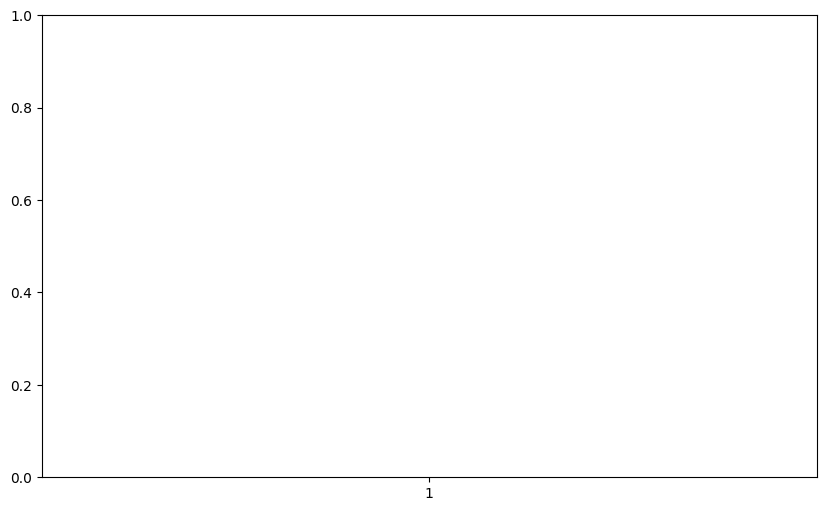

In [20]:
plot_boxplots(df_performance_first, y='Goodput (requests/second)', title='Distribution of Goodput [req/s]')

ValueError: cannot reindex on an axis with duplicate labels

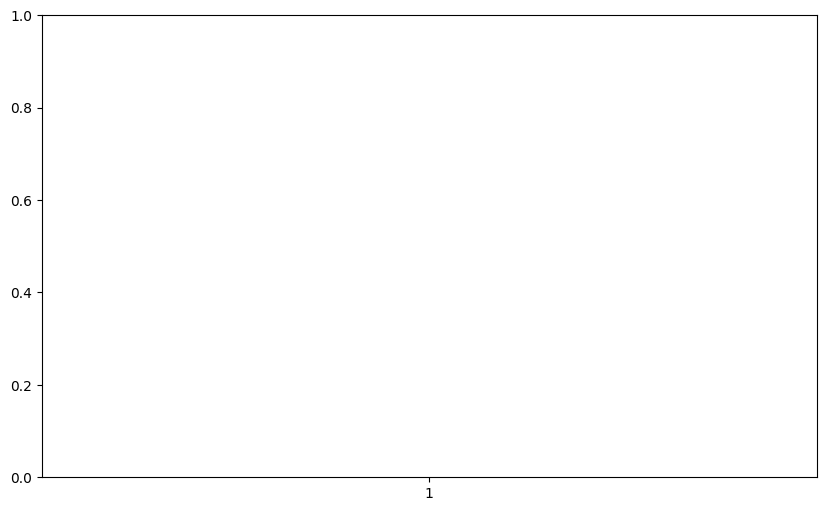

In [21]:
plot_boxplots(df_performance_first, y='Latency Distribution.99th Percentile Latency (microseconds)', title='Distribution of 99th Latency [$\mu s$]')

# Performance Results per Total

In [12]:
df_performance = collect.get_performance_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.dropna(inplace=True)
df_performance

,client,Goodput (requests/second),num_errors,Latency Distribution.Average Latency (microseconds),Latency Distribution.99th Percentile Latency (microseconds),type,num_tenants,vol_tenants,code
0,1,1524.633280,9,64993.000000,397295.0,container,1,False,1765213612
1,2,3538.563101,61,27896.000000,128292.0,container,1,False,1765213612
0,1,1736.463186,12,57050.000000,187902.0,database,1,False,1765211491
1,2,4005.833289,33,24616.000000,107335.0,database,1,False,1765211491
0,1,1696.088278,15,58398.000000,251397.0,schema,1,False,1765209745
1,2,3961.559742,54,24879.000000,109089.0,schema,1,False,1765209745
0,1,3568.128131,42,55463.000000,223755.0,container,2,False,1765219346
1,2,7062.449842,115,27891.500000,116045.0,container,2,False,1765219346
0,1,2055.403145,11,96509.500000,546708.0,database,2,False,1765217176
1,2,6226.968248,106,31642.000000,130306.0,database,2,False,1765217176


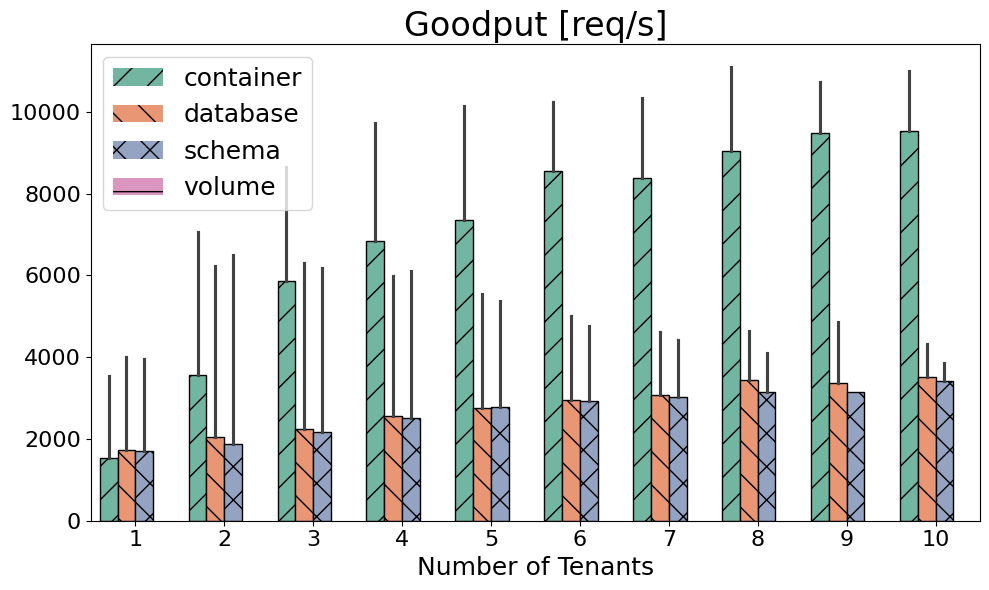

In [13]:
plot_bars(df_performance, y='Goodput (requests/second)', title='Goodput [req/s]', estimator='min')

ValueError: cannot reindex on an axis with duplicate labels

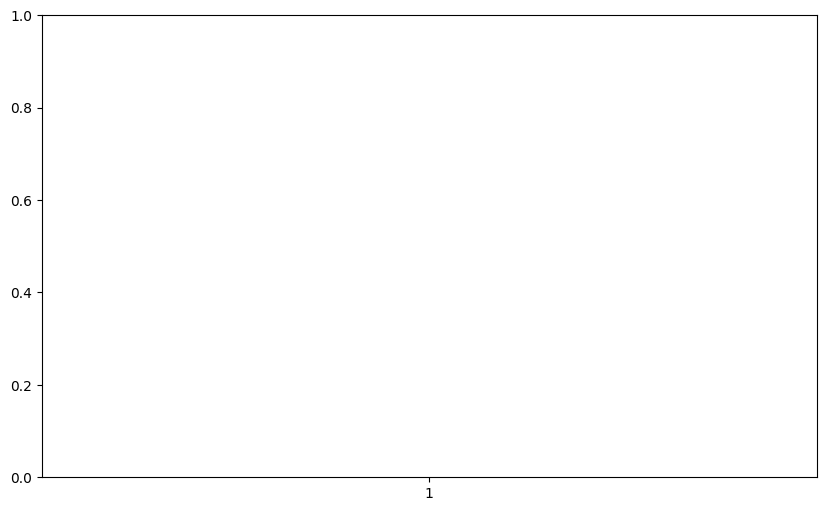

In [22]:
plot_bars(df_performance, y='Latency Distribution.Average Latency (microseconds)', title='Latency [$\mu s$]', estimator='max')

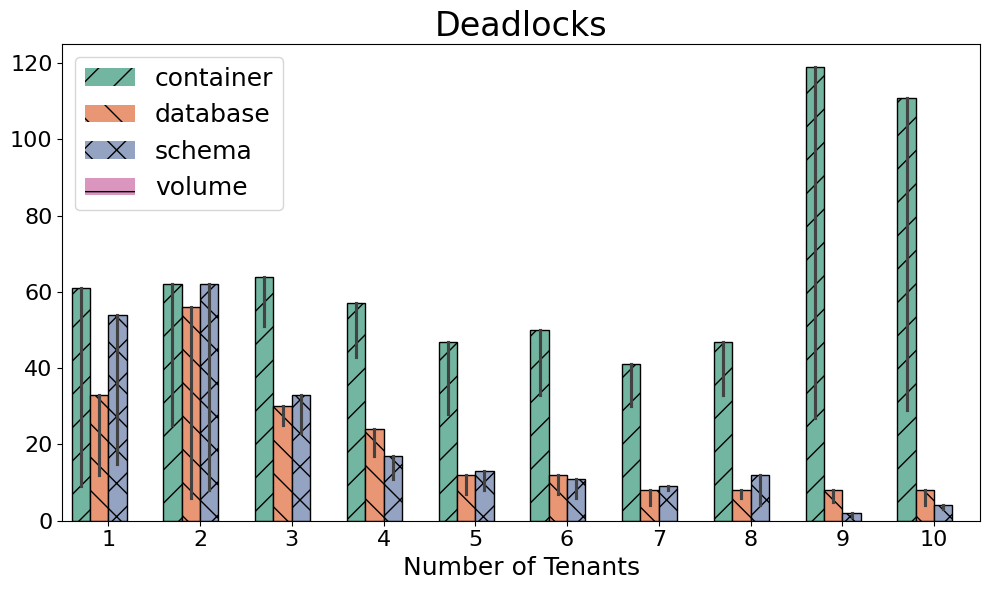

In [23]:
plot_bars(df_performance, y='num_errors', title='Deadlocks', estimator='max')

In [24]:
df_performance = collect.get_loading_time_max_all()
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

,time_load,time_ingest,time_check,terminals,pods,tenant,client,datadisk,type,num_tenants,vol_tenants,code
PostgreSQL-1-1-65536-0-1,281.0,110.0,171.0,1,1,0,1,2720,container,1,False,1765213612
PostgreSQL-1-1-65536-0-2,281.0,110.0,171.0,1,1,0,2,5267,container,1,False,1765213612
PostgreSQL-1-1-65536-1,281.0,104.0,177.0,1,1,,1,2727,database,1,False,1765211491
PostgreSQL-1-1-65536-2,281.0,104.0,177.0,1,1,,2,5611,database,1,False,1765211491
PostgreSQL-1-1-65536-1,280.0,102.0,177.0,1,1,,1,2720,schema,1,False,1765209745
PostgreSQL-1-1-65536-2,280.0,102.0,177.0,1,1,,2,5546,schema,1,False,1765209745
PostgreSQL-1-1-65536-0-1,360.0,138.0,222.0,1,1,0,1,2720,container,2,False,1765219346
PostgreSQL-1-1-65536-0-2,360.0,138.0,222.0,1,1,0,2,5788,container,2,False,1765219346
PostgreSQL-1-1-65536-1-1,366.0,144.0,222.0,1,1,1,1,2721,container,2,False,1765219346
PostgreSQL-1-1-65536-1-2,366.0,144.0,222.0,1,1,1,2,5622,container,2,False,1765219346


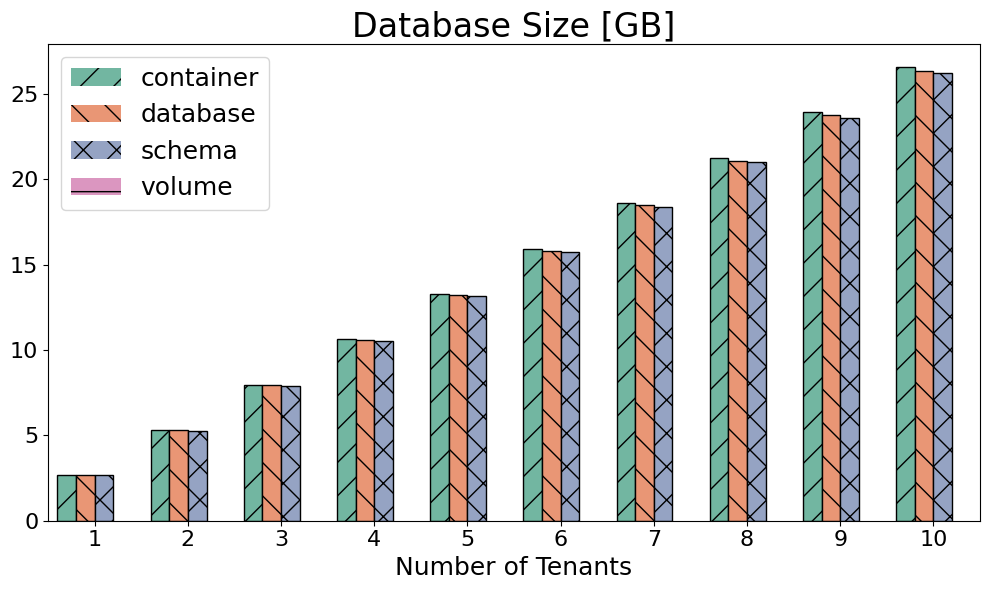

In [25]:
df_performance_first = df_performance[df_performance['client'] == '1']
# Divide datadisk by the count of rows with the same type and num_tenants
df = df_performance_first.copy()
# Create a mask for rows where type is not "container"
mask = df['type'] != 'container'

# Only apply the group count to the relevant rows
group_counts = df[mask].groupby(['type', 'num_tenants'])['datadisk'].transform('count')

# Initialize the column with NaN (or 0, if preferred)
df['datadisk_normalized'] = df['datadisk'] / 1024

# Apply the normalized value only where the mask is True
df.loc[mask, 'datadisk_normalized'] = df.loc[mask, 'datadisk'] / group_counts / 1024

plot_bars(df, y='datadisk_normalized', title='Database Size [GB]', estimator='sum')

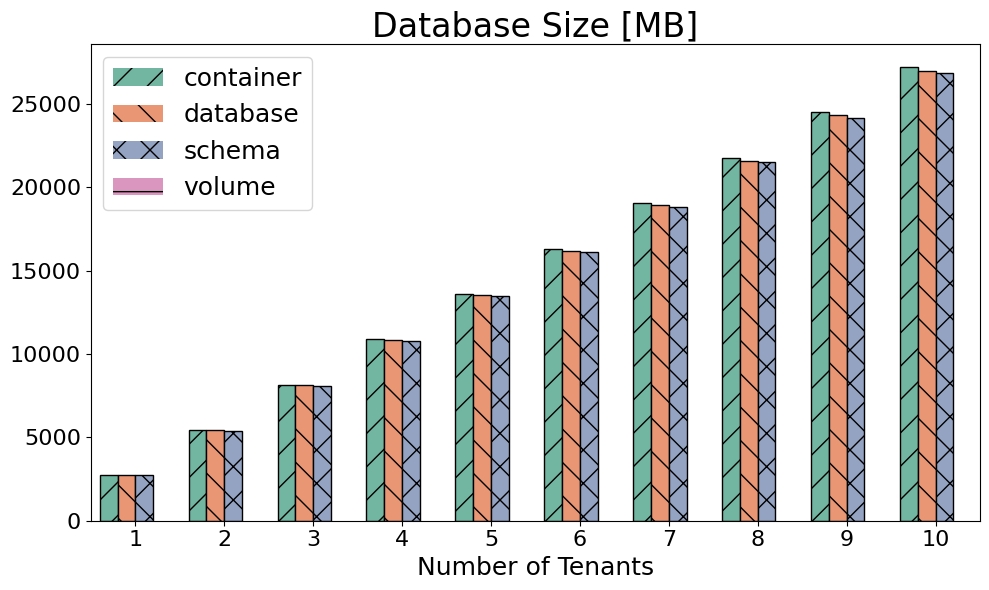

In [26]:
plot_bars(df_performance_first, y='datadisk', title='Database Size [MB]', estimator='sum')

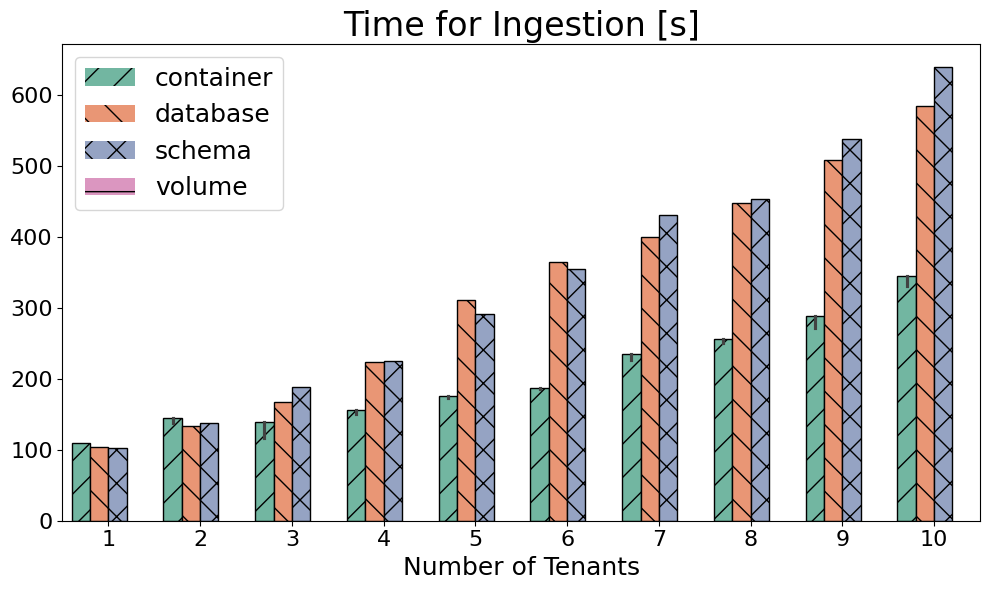

In [27]:
plot_bars(df_performance_first, y='time_ingest', title='Time for Ingestion [s]', estimator='max')

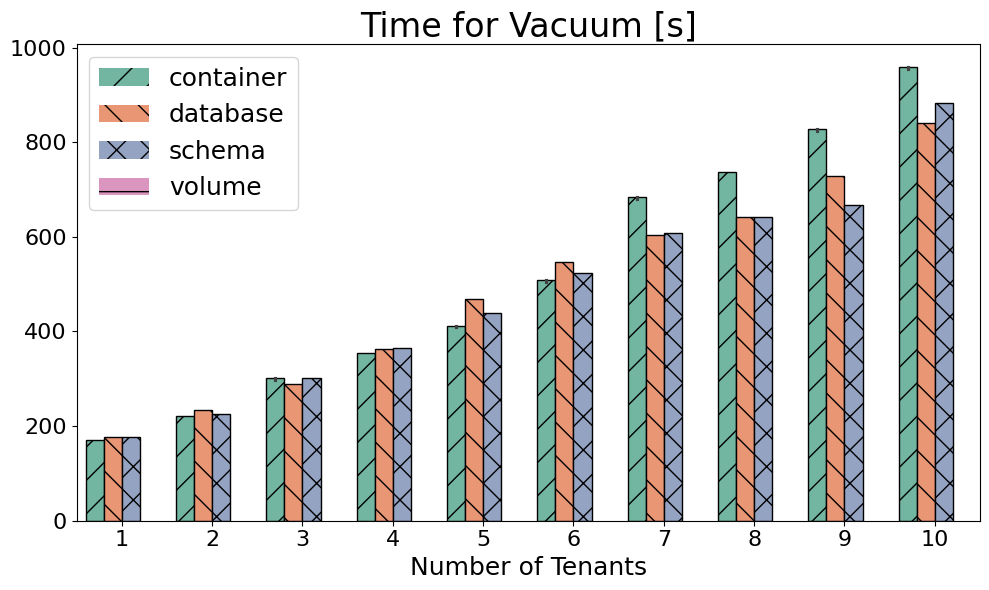

In [28]:
plot_bars(df_performance_first, y='time_check', title='Time for Vacuum [s]', estimator='max')

# Hardware Monitoring for Benchmarking Phase

In [ ]:
df_performance = collect.get_monitoring_all(type="stream")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance.T

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU Utilization Time [s]', estimator='max')

In [ ]:
plot_bars(df_performance, y='Max Core Utilization [%]', title='Max Core Utilization [%]', estimator='sum')

In [ ]:
#plot_bars(df_performance, y='CPU Throttled', title='CPU Throttled', estimator='sum')

In [ ]:
plot_bars(df_performance, y='Memory Usage [MiB]', title='Memory Usage [MiB]', estimator='sum')

In [ ]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Hardware Monitoring for Loading Phase

In [ ]:
df_performance = collect.get_monitoring_all("loading")
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'

df_performance_first = df_performance[df_performance['client']=='1']
df_performance_second = df_performance[df_performance['client']=='2']

df_performance

In [ ]:
plot_bars(df_performance, y='CPU Utilization Time [s]', title='CPU Utilization Time [s]', estimator='max')

In [ ]:
plot_bars(df_performance, y='Max Core Utilization [%]', title='Max Core Utilization [%]', estimator='sum')

In [ ]:
plot_bars(df_performance, y='Memory Usage Cached [MiB]', title='Memory Usage Cached [MiB]', estimator='sum')

# Efficiency

In [ ]:
client = '1'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance_monitoring.loc[df_performance_monitoring['vol_tenants'] == True, 'type'] = 'volume'
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='1st run - $E_{Lat}$', estimator='max')

In [ ]:
#plot_bars(merged_df, y='I_Lat', title='1st run - $I_{Lat}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='1st run - $E_{Tpx}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_RAM', title='1st run - $E_{RAM}$', estimator='min')

In [ ]:
client = '2'

df_performance_monitoring = collect.get_monitoring_all(type="stream")
df_performance_monitoring = df_performance_monitoring[df_performance_monitoring['client'] == client]
df_performance_monitoring.loc[df_performance_monitoring['vol_tenants'] == True, 'type'] = 'volume'
df_performance = collect.get_performance_all()
df_performance = df_performance[df_performance['client'] == client]
df_performance.loc[df_performance['vol_tenants'] == True, 'type'] = 'volume'
merged_df = pd.merge(df_performance, df_performance_monitoring, on=['type', 'num_tenants', 'code', 'client'], how='inner')
#merged_df['I_Lat'] = 1./merged_df['E_Lat']
merged_df['E_Tpx'] = merged_df['Goodput (requests/second)'] / merged_df['CPU Utilization Time [s]'] * 600.
merged_df['E_Lat'] = 1./np.sqrt(merged_df['Latency Distribution.Average Latency (microseconds)']*merged_df['CPU Utilization Time [s]']/1E6)
merged_df['E_RAM'] = (merged_df['Goodput (requests/second)']) / merged_df['Memory Usage [MiB]']
merged_df

In [ ]:
plot_bars(merged_df, y='E_Lat', title='2nd run - $E_{Lat}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_Tpx', title='2nd run - $E_{Tpx}$', estimator='max')

In [ ]:
plot_bars(merged_df, y='E_RAM', title='2nd run - $E_{RAM}$', estimator='max')

In [ ]:
import os
import zipfile

def zip_all_results():
    # Set the base directory containing the folders
    base_dir = path # "/path/to/your/folders"  # CHANGE THIS to your actual directory
    # List all folder names in the directory
    folder_names = codes
    # Create a zip for each folder
    for folder in folder_names:
        folder_path = os.path.join(base_dir, folder)
        zip_path = os.path.join(base_dir, f"{folder}.zip")
        print(f"Zipping {folder_path} to {zip_path}...")
        with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
            for root, _, files in os.walk(folder_path):
                for file in files:
                    abs_path = os.path.join(root, file)
                    rel_path = os.path.relpath(abs_path, folder_path)
                    zipf.write(abs_path, arcname=os.path.join(folder, rel_path))
    print("✅ Done zipping all folders.")


In [ ]:
zip_all_results()